2. Data Augmentation 

Apply augmentation techniques such as: 

• rotation 

• horizontal flip 

• zoom 

• width/height shift 

Train the CNN again and compare results.

In [ ]:
# 1. Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras import optimizers
from tensorflow.keras.layers import Input
import matplotlib.pyplot as plt

In [ ]:
# 2. Set Dataset Path
train_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_train"
test_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_test"
validation_dir = "/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/seg_validate"


In [ ]:
# Image Augmentation (train only)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,          # reduced (faster)
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True
)

validation_datagen = ImageDataGenerator(rescale=1./255)

#Faster config
IMG_SIZE = (128, 128)
BATCH_SIZE = 64

# Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'   #auto multi-class
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Check classes
print("Classes:", train_generator.class_indices)


Found 11229 images belonging to 6 classes.
Found 2805 images belonging to 6 classes.


In [ ]:
#4. Load Test Data
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=64,
    #target_size=(150,150),
    #batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3000 images belonging to 6 classes.


In [ ]:
#Build CNN Model
# Creates a Sequential model 
model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(6, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1774415626.666496      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774415626.672684      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
#6. Compile Model
model.compile(
    optimizer='adam', #faster than RMSprop
    loss='categorical_crossentropy', #correct for multi-class
    metrics=['accuracy']
)

In [ ]:
# 7. Train Model
history = model.fit(
    train_generator,
    epochs=30, 
    validation_data=validation_generator
)


Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 80s 219ms/step - accuracy: 0.4015 - loss: 1.5165 - val_accuracy: 0.6053 - val_loss: 1.0453
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.5664 - loss: 1.1257 - val_accuracy: 0.6881 - val_loss: 0.8602
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 75s 213ms/step - accuracy: 0.5940 - loss: 1.0587 - val_accuracy: 0.6535 - val_loss: 0.9127
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.6115 - loss: 1.0347 - val_accuracy: 0.7280 - val_loss: 0.7896
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 200ms/step - accuracy: 0.6313 - loss: 0.9827 - val_accuracy: 0.7330 - val_loss: 0.7485
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 72s 204ms/step - accuracy: 0.6633 - loss: 0.9110 - val_accuracy: 0.7387 - val_loss: 0.7350
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 202ms/step - accuracy: 0.6588 - loss: 0.9064 - val_accuracy: 0.7544 - val_loss: 0.7014
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 71s 201ms/step - accuracy: 0.6682 - loss: 0

In [ ]:
# Save model
model.save("/kaggle/input/datasets/retreattechnology/buildingstreet-image-classification-dataset/Intel_Image_Classification_Dataset/Augmentation_model_2_Assignment.h5")

In [ ]:
# Evaluate on Test Data
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.8355 - loss: 0.4579
Test Accuracy: 0.7570000290870667
Test Loss: 0.6633250117301941


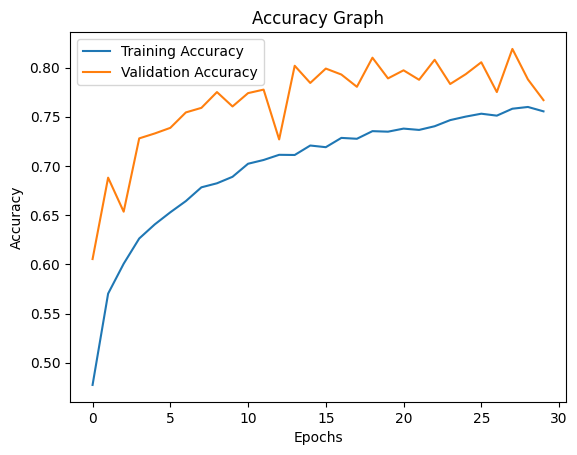

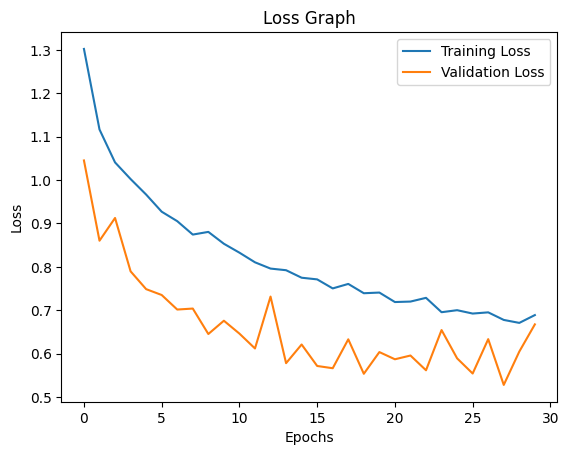

In [ ]:
# Accuracy & Loss Graphs
# Accuracy Plot
plt.figure()
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

# Loss Plot
plt.figure()
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Graph")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()